
# Accuracy vs Time (Classification) — Minimal Research Notebook
**Generated:** 2025-09-18 14:36:39

This notebook measures **test accuracy vs cumulative fit time** for several classifiers, including **TabPFN** and **AutoTabPFN**.
It is intentionally minimal: no try/except, no optional branching, and only essential outputs.


In [1]:
from IPython.display import display, HTML
from tqdm.notebook import tqdm
import subprocess

# --- Phase 1: Lightweight packages ---
phase1 = [
    "scikit-learn==1.5.2",
    "tabpfn",
    "catboost",
    "xgboost",
    "lightgbm",
    "datasets",
    "ucimlrepo",
    "ace_tools"
]

# --- Phase 2: Heavy or Git-based packages ---
phase2 = [
    "autogluon==0.8.2 --no-cache-dir --upgrade",
    "tabpfn-extensions[all] @ git+https://github.com/PriorLabs/tabpfn-extensions.git"
]

# --- Function to install packages with live output ---
def install_packages(package_list, phase_name):
    logs = []
    display(HTML(f"<h3>🚀 Starting {phase_name}</h3>"))
    for pkg in tqdm(package_list, desc=f"{phase_name}", unit="pkg"):
        display(HTML(f"<b>Installing:</b> {pkg}"))
        process = subprocess.Popen(
            ["pip", "install", "--no-cache-dir", "--upgrade", pkg],
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True
        )
        output = ""
        for line in process.stdout:
            output += line
        process.wait()
        logs.append(f"📦 {pkg}\n{output}")
    return logs

# --- Run both phases ---
logs_phase1 = install_packages(phase1, "Phase 1: Core Packages")
logs_phase2 = install_packages(phase2, "Phase 2: Heavy/Git Packages")

# --- Display combined logs ---
all_logs = logs_phase1 + logs_phase2
scrollable_logs = (
    "<pre style='max-height: 400px; overflow-y: scroll; border: 1px solid #ccc; padding: 10px;'>"
    + "\n\n".join(all_logs) + "</pre>"
)
display(HTML(scrollable_logs))

Phase 1: Core Packages:   0%|          | 0/8 [00:00<?, ?pkg/s]

Phase 2: Heavy/Git Packages:   0%|          | 0/2 [00:00<?, ?pkg/s]

In [2]:
# %% [setup] Imports
import math, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

from tabpfn import TabPFNClassifier
#   raise SystemError('Please restart the session to fix this import.')
from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import AutoTabPFNClassifier

Email (optional, press Enter to skip):  y


Enable anonymous usage analytics? [y/n]:  y



## Data
Set `CSV_PATH` and `TARGET_COL` to use your dataset; otherwise a standard dataset is used.


In [3]:
# %% [data] Load data
CSV_PATH = ""  # e.g., "/mnt/data/your_classification.csv"
TARGET_COL = ""  # e.g., "label"

if CSV_PATH and TARGET_COL:
    df = pd.read_csv(CSV_PATH)
    y = df[TARGET_COL]
    X = df.drop(columns=[TARGET_COL])
else:
    from sklearn.datasets import load_breast_cancer
    data = load_breast_cancer(as_frame=True)
    X = data.data
    y = data.target

if not isinstance(X, pd.DataFrame):
    X = pd.DataFrame(X)

if not np.issubdtype(np.asarray(y).dtype, np.number):
    y = LabelEncoder().fit_transform(np.asarray(y))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


## Preprocessing
Numeric: median impute + standardize.  
Categorical: most-frequent impute + one-hot.  
TabPFN: numeric-only impute (dense).


In [4]:
# %% [preprocess] Pipelines
numeric_selector = selector(dtype_include=np.number)
categorical_selector = selector(dtype_exclude=np.number)

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_selector),
    ("cat", categorical_transformer, categorical_selector),
], remainder="drop")

tabpfn_pre = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_selector),
], remainder="drop")


## Models
Baseline sklearn models + CatBoost, LightGBM, TabPFN, AutoTabPFN.


In [5]:
# %% [models] Define models
models = [
    ("LogisticRegression", Pipeline([("pre", preprocessor), ("clf", LogisticRegression(max_iter=2000))])),
    ("RandomForest",      Pipeline([("pre", preprocessor), ("clf", RandomForestClassifier(n_estimators=300, random_state=42))])),
    ("SVC",               Pipeline([("pre", preprocessor), ("clf", SVC(kernel="rbf", probability=True, random_state=42))])),
    ("MLP",               Pipeline([("pre", preprocessor), ("clf", MLPClassifier(hidden_layer_sizes=(128,64), max_iter=600, random_state=42))])),
    ("CatBoost",          Pipeline([("pre", preprocessor), ("clf", CatBoostClassifier(verbose=False, random_seed=42, iterations=500, learning_rate=0.05, depth=6))])),
    ("LightGBM",          Pipeline([("pre", preprocessor), ("clf", LGBMClassifier(n_estimators=500, learning_rate=0.05, max_depth=-1, random_state=42))])),
    ("TabPFN",            Pipeline([("pre_simple", tabpfn_pre), ("clf", TabPFNClassifier())])),
    ("AutoTabPFN",        Pipeline([("pre", preprocessor), ("clf", AutoTabPFNClassifier())])),
]


## Benchmark: Accuracy vs Cumulative Time
Trains each model on increasing fractions of the training set and measures test accuracy.


In [6]:
# %% [benchmark] Accuracy vs Time
fractions = [0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0]

records = []
n = len(X_train)
idx = np.arange(n)

for name, pipe in models:
    cumulative_time = 0.0
    for f in fractions:
        k = max(5, int(math.ceil(f * n)))
        sub_idx = idx[:k]
        X_sub = X_train.iloc[sub_idx]
        y_sub = y_train[sub_idx] if isinstance(y_train, np.ndarray) else y_train.iloc[sub_idx]

        t0 = time.time()
        pipe.fit(X_sub, y_sub)
        t1 = time.time()

        cumulative_time += (t1 - t0)
        y_pred = pipe.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        records.append({
            "Model": name,
            "Fraction": f,
            "TrainSamples": k,
            "CumulativeFitTimeSec": cumulative_time,
            "Accuracy": acc
        })

results = pd.DataFrame(records)
results.to_csv("classification_accuracy_time_results_MINIMAL.csv", index=False)
results.head()

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Number of positive: 16, number of negative: 7
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 23, number of used features: 0
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.695652 -> initscore=0.826679
[LightGBM] [Info] Start training from score 0.826679
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because ther

tabpfn-v2-classifier-finetuned-zk73skhh.(…):   0%|          | 0.00/29.0M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

tabpfn-v2-classifier-znskzxi4.ckpt:   0%|          | 0.00/12.9M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

...

tabpfn-v2-classifier-vutqq28w.ckpt:   0%|          | 0.00/12.9M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

tabpfn-v2-classifier-od3j1g5m.ckpt:   0%|          | 0.00/29.0M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

,Model,Fraction,TrainSamples,CumulativeFitTimeSec,Accuracy
0,LogisticRegression,0.05,23,0.034335,0.947368
1,LogisticRegression,0.10,46,0.045116,0.964912
2,LogisticRegression,0.20,91,0.055234,0.956140
3,LogisticRegression,0.40,182,0.066088,0.982456
4,LogisticRegression,0.60,273,0.253408,0.982456


In [13]:
results.tail()

,Model,Fraction,TrainSamples,CumulativeFitTimeSec,Accuracy
51,AutoTabPFN,0.2,91,342.759920,0.929825
52,AutoTabPFN,0.4,182,461.407154,0.956140
53,AutoTabPFN,0.6,273,584.068066,0.964912
54,AutoTabPFN,0.8,364,714.752145,0.973684
55,AutoTabPFN,1.0,455,855.003643,0.973684



## Plot: Accuracy vs Cumulative Fit Time
One figure, all models.


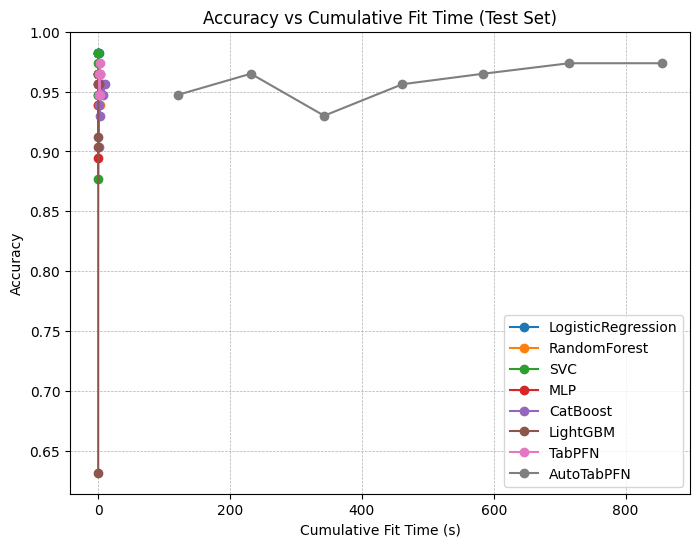

In [7]:
# %% [plot] Accuracy vs Time
plt.figure(figsize=(8,6))
for name in results["Model"].unique():
    sub = results[results["Model"] == name].sort_values("CumulativeFitTimeSec")
    plt.plot(sub["CumulativeFitTimeSec"].values, sub["Accuracy"].values, marker="o", label=name)

plt.xlabel("Cumulative Fit Time (s)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Cumulative Fit Time (Test Set)")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5)
plt.show()

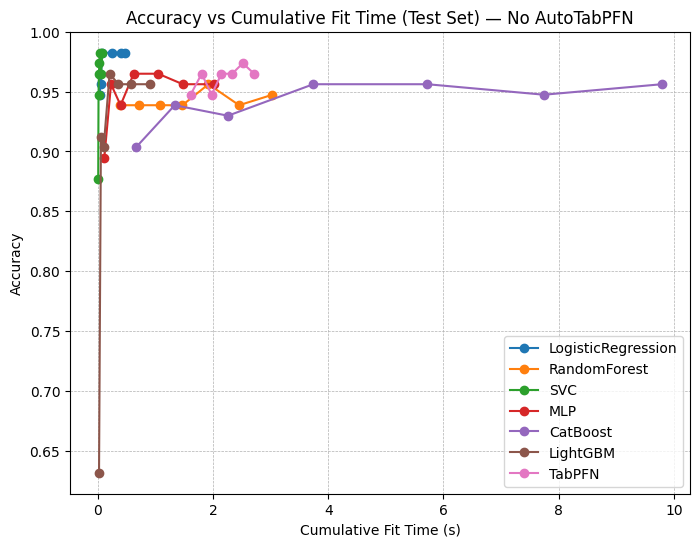

In [8]:
# %% [plot] Accuracy vs Time (excluding AutoTabPFN)
res_no_auto = results[results["Model"] != "AutoTabPFN"]  # exact match; adjust if your label differs

plt.figure(figsize=(8,6))
for name in res_no_auto["Model"].unique():
    sub = res_no_auto[res_no_auto["Model"] == name].sort_values("CumulativeFitTimeSec")
    plt.plot(sub["CumulativeFitTimeSec"].values, sub["Accuracy"].values, marker="o", label=name)

plt.xlabel("Cumulative Fit Time (s)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Cumulative Fit Time (Test Set) — No AutoTabPFN")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5)
plt.show()

In [9]:
# If plotly isn't installed in your env, run this once:
!pip install plotly

In [11]:
# %% (optional) %pip install plotly
import plotly.graph_objects as go
import numpy as np

df = results.copy().sort_values(["Model", "CumulativeFitTimeSec"])
df["acc0"] = df.groupby("Model")["Accuracy"].transform("first")

models = df["Model"].unique().tolist()
band_height = 0.15
scale = 1.0
y0_map = {m: i*band_height for i, m in enumerate(models)}

df["y_adj"] = df.apply(lambda r: y0_map[r["Model"]] + (r["Accuracy"] - r["acc0"])*scale, axis=1)

fig = go.Figure()
for m in models:
    sub = df[df["Model"] == m]
    fig.add_trace(go.Scatter(
        x=sub["CumulativeFitTimeSec"],
        y=sub["y_adj"],
        mode="lines+markers",
        name=m,
        hovertemplate=(
            "Model: %{text}<br>"
            "Time (s): %{x:.2f}<br>"
            "Accuracy: %{customdata:.4f}<br>"
            "Δ from start: %{y:.4f}"
        ),
        text=[m]*len(sub),
        customdata=sub["Accuracy"],
    ))

fig.update_layout(
    title="Accuracy vs Time — Model-Specific Baselines (Interactive)",
    xaxis_title="Cumulative Fit Time (s)",
    yaxis=dict(
        tickmode="array",
        tickvals=[y0_map[m] for m in models],
        ticktext=models,
        zeroline=False
    ),
    template="plotly_white",
    hovermode="x unified",
    margin=dict(l=60, r=20, t=60, b=60)
)

# Optional horizontal guides
for y in [y0_map[m] for m in models]:
    fig.add_hline(y=y, line_width=1, line_dash="dot", opacity=0.4)

fig.show()

In [12]:
# %% [plot] Accuracy vs Time — dropdown to choose model
# (Run once: %pip install plotly)
import plotly.graph_objects as go

df = results.sort_values(["Model", "CumulativeFitTimeSec"]).copy()
models = df["Model"].unique().tolist()

fig = go.Figure()

# one trace per model (all shown initially)
for m in models:
    sub = df[df["Model"] == m]
    fig.add_trace(go.Scatter(
        x=sub["CumulativeFitTimeSec"],
        y=sub["Accuracy"],
        mode="lines+markers",
        name=m,
        visible=True
    ))

# dropdown buttons: "All" + per-model
buttons = []
# All
buttons.append(dict(
    label="All",
    method="update",
    args=[{"visible": [True]*len(models)},
          {"title": "Accuracy vs Cumulative Time — All Models"}]
))
# Each model
for i, m in enumerate(models):
    vis = [False]*len(models)
    vis[i] = True
    buttons.append(dict(
        label=m,
        method="update",
        args=[{"visible": vis},
              {"title": f"Accuracy vs Cumulative Time — {m}"}]
    ))

fig.update_layout(
    title="Accuracy vs Cumulative Time — All Models",
    xaxis_title="Cumulative Fit Time (s)",
    yaxis_title="Accuracy",
    template="plotly_white",
    legend_title_text="Model",
    updatemenus=[dict(
        type="dropdown",
        x=1.0, xanchor="right",
        y=1.15, yanchor="top",
        buttons=buttons
    )]
)

fig.show()